# STAC 

In [1]:
# pystac_client = 
    # - Python-Bibliothek zum Abfragen von STAC-APIs (SpatioTemporal Asset Catalog)
    # - "Suchmaschine" für Geodaten: Filter nach Bbox, Zeitraum, Cloud-Cover etc.
    # - liefert Metadaten + Asset-Links zu Satellitenszenen zurueck, kein Download noetig
# planetary_computer
    # - Microsoft-Erweiterung/SDK fuer den Planetary Computer STAC-Katalog
    # - stellt kostenlosen Zugriff auf Sentinel-2 & andere Satellitendaten (Azure Storage) bereit
    # - sign_inplace haengt automatisch ein temporaeres SAS-Token an jede Asset-URL
    #   (Authentifizierung-as-a-Service, ohne eigene Credentials)  

In [ ]:
# Für zwei Zeiträume ("datetime") ausgelesen:
# 1. Quartal 1 in 2020 und
# 2. Quartal 4 in 2020

In [26]:
import pystac_client
import planetary_computer

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

BBOX = (88.0, 21.3, 90.7, 23.0)  # gleiche Bbox wie Notebook 02

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=BBOX,
    datetime="2020-10-01/2020-12-31",
    query={"eo:cloud_cover": {"lt": 10}},
)

items = list(search.items())
print(f"Gefundene Szenen: {len(items)}")
for item in items:
    print(item.id, "| Cloud Cover:", item.properties["eo:cloud_cover"], "| Datum:", item.datetime.date())

Gefundene Szenen: 188
S2B_MSIL2A_20201230T044209_R033_T45QYF_20201230T135827 | Cloud Cover: 0.021705 | Datum: 2020-12-30
S2B_MSIL2A_20201230T044209_R033_T45QYE_20201230T140102 | Cloud Cover: 0.046824 | Datum: 2020-12-30
S2B_MSIL2A_20201230T044209_R033_T45QYD_20201230T140038 | Cloud Cover: 0.000834 | Datum: 2020-12-30
S2B_MSIL2A_20201230T044209_R033_T45QXF_20201230T135557 | Cloud Cover: 0.062983 | Datum: 2020-12-30
S2B_MSIL2A_20201230T044209_R033_T45QXE_20201230T135734 | Cloud Cover: 0.128115 | Datum: 2020-12-30
S2B_MSIL2A_20201230T044209_R033_T45QXD_20201230T135730 | Cloud Cover: 0.010823 | Datum: 2020-12-30
S2B_MSIL2A_20201230T044209_R033_T45QWF_20201230T135626 | Cloud Cover: 0.443369 | Datum: 2020-12-30
S2B_MSIL2A_20201230T044209_R033_T45QWE_20201230T140045 | Cloud Cover: 0.510974 | Datum: 2020-12-30
S2B_MSIL2A_20201230T044209_R033_T45QWD_20201230T135634 | Cloud Cover: 0.145159 | Datum: 2020-12-30
S2B_MSIL2A_20201227T043209_R133_T46QBL_20201227T152051 | Cloud Cover: 0.070746 | Datum:

In [3]:
# 210 Bilder brauche ich nicht, daher die 10 wolkenärmsten auswählen:
import pandas as pd

records = [
    {
        "id": item.id,
        "datetime": item.datetime.date(),
        "cloud_cover": item.properties["eo:cloud_cover"],
        "tile": item.properties.get("s2:mgrs_tile"),
    }
    for item in items
]

df_items = pd.DataFrame(records).sort_values("cloud_cover").reset_index(drop=True)
df_items.head(10)

,id,datetime,cloud_cover,tile
0,S2A_MSIL2A_20200117T043121_R133_T46QBJ_2020100...,2020-01-17,0.000003,46QBJ
1,S2A_MSIL2A_20200117T043121_R133_T45QZD_2020100...,2020-01-17,0.000007,45QZD
2,S2A_MSIL2A_20200107T043141_R133_T46QBJ_2020102...,2020-01-07,0.000007,46QBJ
3,S2A_MSIL2A_20200107T043141_R133_T45QZD_2020102...,2020-01-07,0.000020,45QZD
4,S2B_MSIL2A_20200201T043009_R133_T45QZD_2020093...,2020-02-01,0.000040,45QZD
5,S2B_MSIL2A_20200201T043009_R133_T46QBJ_2020093...,2020-02-01,0.000109,46QBJ
6,S2B_MSIL2A_20200211T042919_R133_T45QYD_2020100...,2020-02-11,0.000207,45QYD
7,S2B_MSIL2A_20200214T043859_R033_T45QYD_2020102...,2020-02-14,0.000274,45QYD
8,S2A_MSIL2A_20200216T042841_R133_T45QZD_2020092...,2020-02-16,0.000299,45QZD
9,S2A_MSIL2A_20200117T043121_R133_T45QYD_2020100...,2020-01-17,0.000326,45QYD


In [4]:
# Das wolkenärmste Bild auswählen:
selected_item_id = df_items.loc[0, "id"]
selected_item = next(item for item in items if item.id == selected_item_id)

print("Ausgewählt:", selected_item_id)
print("Cloud Cover:", selected_item.properties["eo:cloud_cover"])
print("Datum:", selected_item.datetime.date())

Ausgewählt: S2A_MSIL2A_20200117T043121_R133_T46QBJ_20201002T194200
Cloud Cover: 3e-06
Datum: 2020-01-17


In [5]:
import rioxarray

bands = {"B04": "red", "B03": "green", "B02": "blue", "B08": "nir"}

data = {}
for band_id, name in bands.items():
    href = selected_item.assets[band_id].href
    da = rioxarray.open_rasterio(href)
    da_clip = da.rio.clip_box(*BBOX, crs="EPSG:4326")
    data[name] = da_clip.squeeze()
    print(name, data[name].shape)

red (4291, 6427)
green (4291, 6427)
blue (4291, 6427)
nir (4291, 6427)


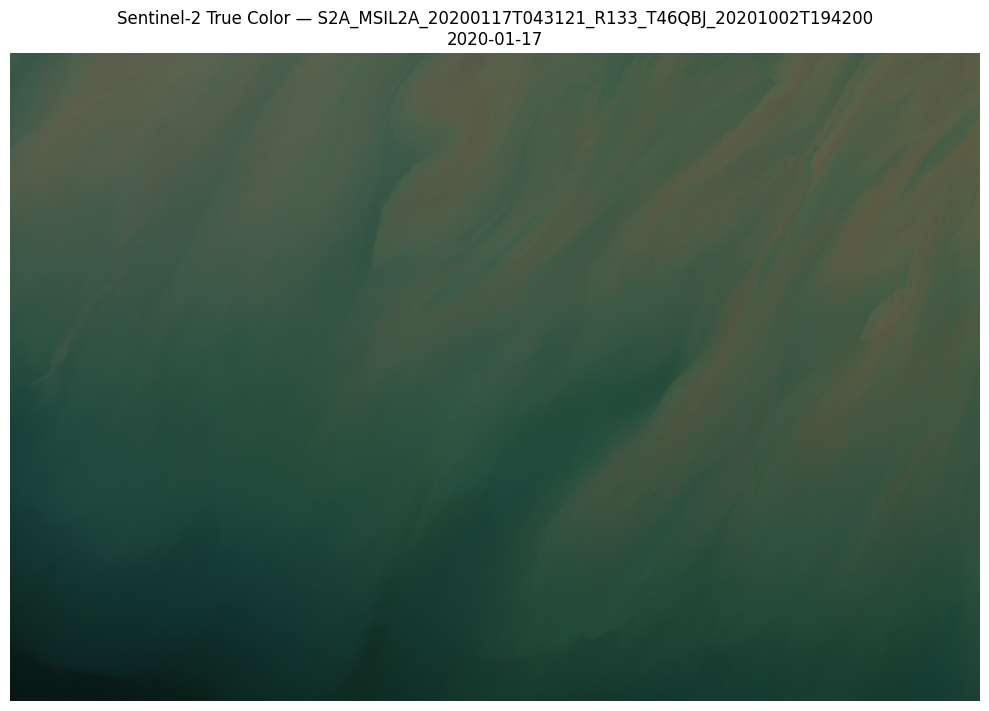

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def normalize(band, low=0, high=3000):
    return np.clip((band - low) / (high - low), 0, 1)

rgb = np.stack([
    normalize(data["red"].values),
    normalize(data["green"].values),
    normalize(data["blue"].values),
], axis=-1)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb)
ax.set_title(f"Sentinel-2 True Color — {selected_item_id}\n{selected_item.datetime.date()}")
ax.axis("off")
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_true-color_2026-06-13.png", dpi=150)
plt.show()

In [7]:
print("Red  - min:", data["red"].values.min(), "max:", data["red"].values.max(), "p98:", np.percentile(data["red"].values, 98))
print("Green- min:", data["green"].values.min(), "max:", data["green"].values.max(), "p98:", np.percentile(data["green"].values, 98))
print("Blue - min:", data["blue"].values.min(), "max:", data["blue"].values.max(), "p98:", np.percentile(data["blue"].values, 98))

Red  - min: 61 max: 3488 p98: 1052.0
Green- min: 231 max: 3142 p98: 1138.0
Blue - min: 186 max: 2468 p98: 907.0


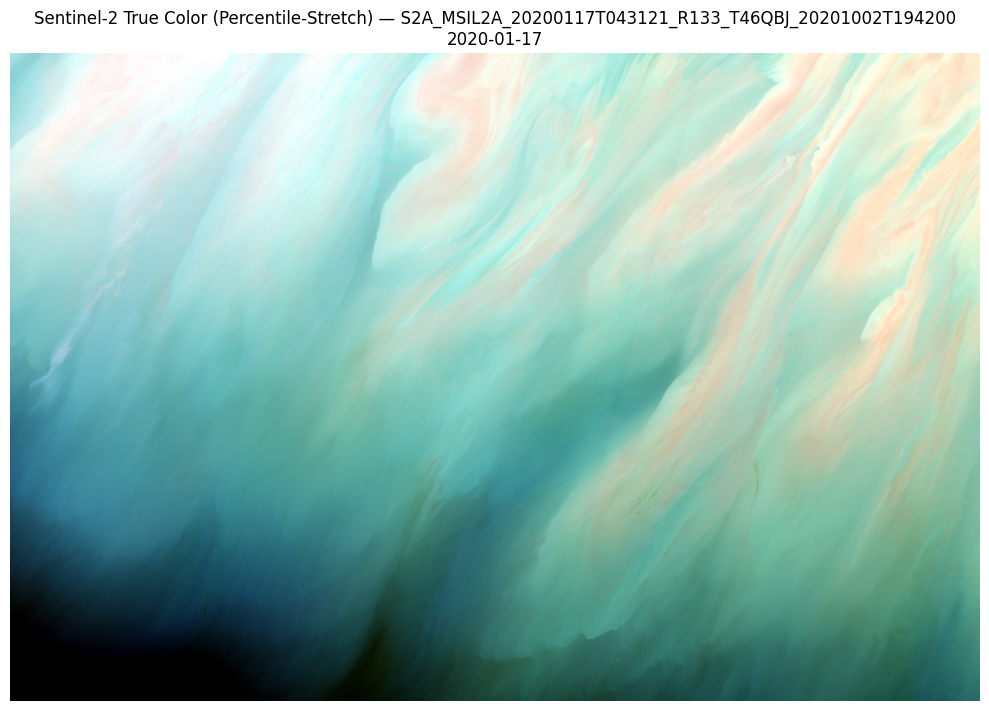

In [8]:
def normalize_pct(band, p_low=2, p_high=98):
    lo, hi = np.percentile(band, [p_low, p_high])
    return np.clip((band - lo) / (hi - lo), 0, 1)

rgb = np.stack([
    normalize_pct(data["red"].values),
    normalize_pct(data["green"].values),
    normalize_pct(data["blue"].values),
], axis=-1)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb)
ax.set_title(f"Sentinel-2 True Color (Percentile-Stretch) — {selected_item_id}\n{selected_item.datetime.date()}")
ax.axis("off")
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_true-color_2026-06-13.png", dpi=150)
plt.show()

In [9]:
print("Bounds der Kachel (geladen):", data["red"].rio.bounds())
print("Bbox angefragt:            ", BBOX)
print("Nodata-Wert:", data["red"].rio.nodata)

vals, counts = np.unique(data["red"].values, return_counts=True)
top_idx = np.argsort(counts)[::-1][:5]
for i in top_idx:
    print(f"Wert {vals[i]}: {counts[i]:,} Pixel ({100*counts[i]/data['red'].size:.1f}%)")

Bounds der Kachel (geladen): (199980.0, 2357090.0, 264250.0, 2400000.0)
Bbox angefragt:             (88.0, 21.3, 90.7, 23.0)
Nodata-Wert: None
Wert 1050: 74,148 Pixel (0.3%)
Wert 1042: 71,072 Pixel (0.3%)
Wert 868: 69,186 Pixel (0.3%)
Wert 874: 69,100 Pixel (0.3%)
Wert 885: 67,770 Pixel (0.2%)


In [10]:
# Was ist NDVI physikalisch? 
# NDVI = (NIR − Red) / (NIR + Red), Wertebereich -1 bis +1. 
# Gesunde Vegetation absorbiert Rotlicht stark (Photosynthese, Chlorophyll) aber 
# reflektiert NIR stark (Zellstruktur der Blätter) → großer Unterschied NIR-Red → 
# hoher NDVI (0.3-0.8+). 
# Wasser absorbiert NIR fast vollständig und reflektiert wenig Rot → NDVI nahe 0 oder
# negativ. 
# Boden/Sand liegt meist dazwischen (0.1-0.3).

NDVI min: -0.9931506849315068 max: 0.2587755102040816 mean: -0.5895458815640506


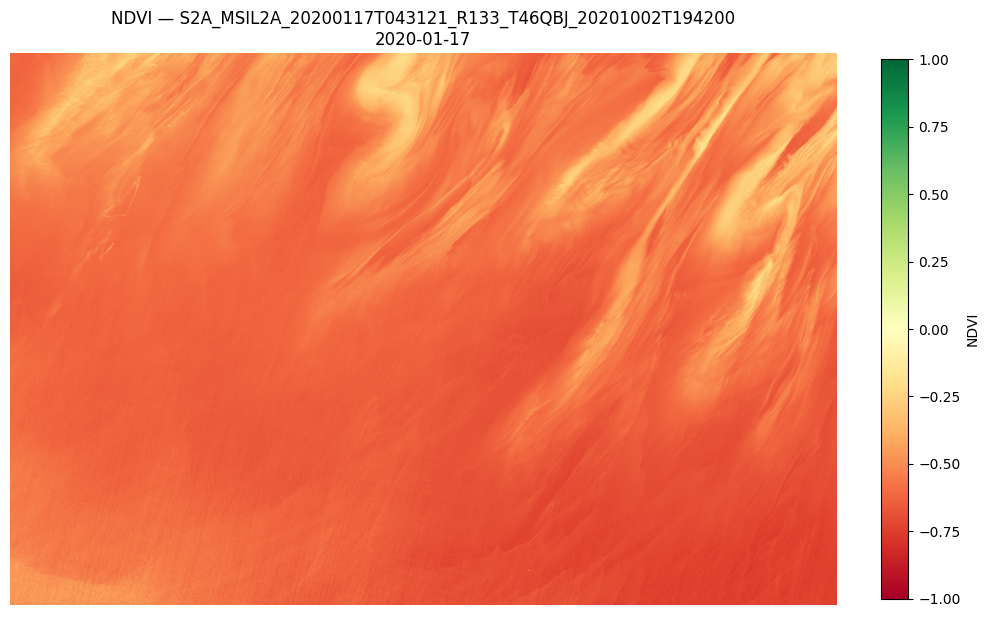

In [11]:
red = data["red"].values.astype(float)
nir = data["nir"].values.astype(float)

ndvi = (nir - red) / (nir + red)

print("NDVI min:", ndvi.min(), "max:", ndvi.max(), "mean:", ndvi.mean())

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_title(f"NDVI — {selected_item_id}\n{selected_item.datetime.date()}")
ax.axis("off")
plt.colorbar(im, ax=ax, label="NDVI", fraction=0.03)
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_ndvi_2026-06-13.png", dpi=150)
plt.show()

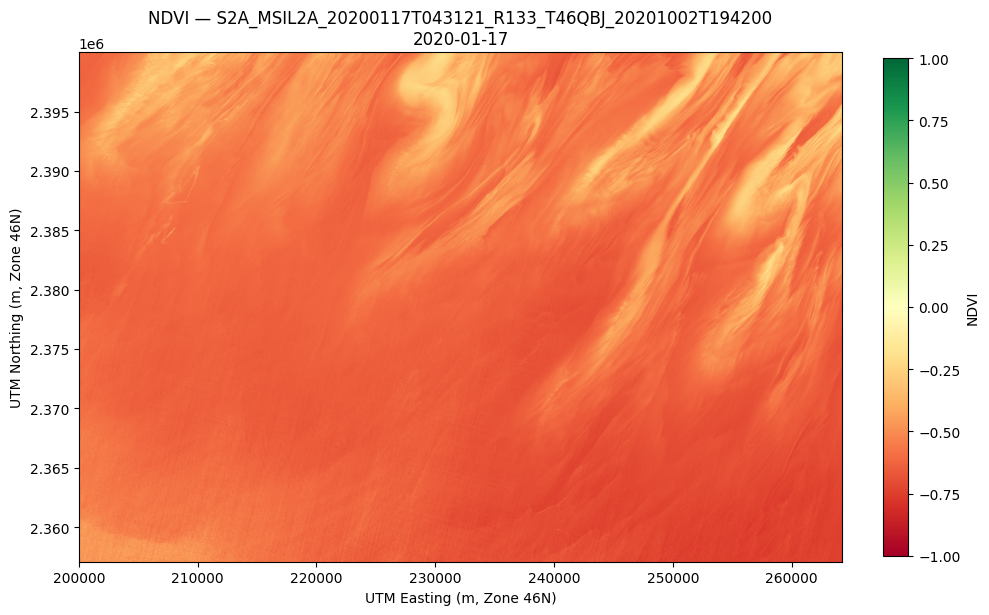

In [12]:
x = data["red"].x.values
y = data["red"].y.values
extent = [x.min(), x.max(), y.min(), y.max()]

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1, extent=extent)
ax.set_title(f"NDVI — {selected_item_id}\n{selected_item.datetime.date()}")
ax.set_xlabel("UTM Easting (m, Zone 46N)")
ax.set_ylabel("UTM Northing (m, Zone 46N)")
plt.colorbar(im, ax=ax, label="NDVI", fraction=0.03)
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_ndvi_2026-06-13.png", dpi=150)
plt.show()

In [13]:
# Global Mangrove Watch-2020-Polygone laden und auf den Ausschnitt zuschneiden
import geopandas as gpd

gmw_2020 = gpd.read_file("../data/raw/gmw_v3_2020/gmw_v3_2020_vec.shp")

bounds = data["red"].rio.bounds()
gmw_utm = gmw_2020.to_crs(data["red"].rio.crs)
gmw_clip = gmw_utm.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]

print(f"GMW-Polygone im Ausschnitt: {len(gmw_clip)}")

GMW-Polygone im Ausschnitt: 0


In [ ]:
# Für Q1 ausgeführt zuerst,
# dann für Quartal 4

In [27]:
# für Q1: für jede der 210 gefundenen Szenen die Überlappung mit GMW-2020-Polygonen in der 
# Bbox berechnen und nach Überlappung sortieren.

# Für Q aus 188 Einträgen auswählen:

from shapely.geometry import shape

gmw_bbox = gmw_2020.cx[BBOX[0]:BBOX[2], BBOX[1]:BBOX[3]]
gmw_union = gmw_bbox.union_all()

overlaps = []
for item in items:
    footprint = shape(item.geometry)
    overlap_area = footprint.intersection(gmw_union).area
    overlaps.append({
        "id": item.id,
        "tile": item.properties.get("s2:mgrs_tile"),
        "cloud_cover": item.properties["eo:cloud_cover"],
        "overlap_deg2": overlap_area,
    })

df_overlap = pd.DataFrame(overlaps).sort_values("overlap_deg2", ascending=False).reset_index(drop=True)
df_overlap.head(10)

,id,tile,cloud_cover,overlap_deg2
0,S2A_MSIL2A_20201112T043031_R133_T45QYE_2020111...,45QYE,2.298159,0.400631
1,S2A_MSIL2A_20201013T042731_R133_T45QYE_2020102...,45QYE,9.964012,0.400596
2,S2A_MSIL2A_20201122T043111_R133_T45QYE_2020112...,45QYE,0.059314,0.400596
3,S2A_MSIL2A_20201222T043211_R133_T45QYE_2020122...,45QYE,1.110492,0.400231
4,S2A_MSIL2A_20201202T043141_R133_T45QYE_2020120...,45QYE,2.978415,0.400198
5,S2B_MSIL2A_20201028T042909_R133_T45QYE_2020110...,45QYE,0.018112,0.400156
6,S2B_MSIL2A_20201207T043149_R133_T45QYE_2020120...,45QYE,0.015847,0.400062
7,S2B_MSIL2A_20201107T042959_R133_T45QYE_2020110...,45QYE,0.006486,0.399971
8,S2B_MSIL2A_20201227T043209_R133_T45QYE_2020122...,45QYE,0.018887,0.399763
9,S2B_MSIL2A_20201217T043159_R133_T45QYE_2021010...,45QYE,0.041170,0.399607


# Untere Zell NUR Für Q4: ID auslesen aus Eintrag 7

In [28]:
# print(df_overlap.loc[7, "id"])
selected_item = next(item for item in items if item.id == df_overlap.loc[7, "id"])
selected_item_id = selected_item.id

print("Q4-Szene:", selected_item_id)
print("Cloud Cover:", selected_item.properties["eo:cloud_cover"])
print("Datum:", selected_item.datetime.date())

data_q4 = {}
for band_id, name in bands.items():
    href = selected_item.assets[band_id].href
    da = rioxarray.open_rasterio(href)
    data_q4[name] = da.rio.clip_box(*BBOX, crs="EPSG:4326").squeeze()

red_q4 = data_q4["red"].values.astype(float)
nir_q4 = data_q4["nir"].values.astype(float)

with np.errstate(divide="ignore", invalid="ignore"):
    ndvi_q4 = (nir_q4 - red_q4) / (nir_q4 + red_q4)

print("NDVI Q1 mean:", np.nanmean(ndvi))
print("NDVI Q4 mean:", np.nanmean(ndvi_q4))

Q4-Szene: S2B_MSIL2A_20201107T042959_R133_T45QYE_20201109T031741
Cloud Cover: 0.006486
Datum: 2020-11-07
NDVI Q1 mean: 0.252391152314466
NDVI Q4 mean: 0.3361269535071426


# Neues Bild ausgewählt, das mit der ursprünglichen Box mehr überschneidet

In [15]:
selected_item_id = "S2B_MSIL2A_20200201T043009_R133_T45QYE_20200930194518"  # ggf. exakte ID aus df_overlap.loc[7, "id"] uebernehmen
selected_item = next(item for item in items if item.id == df_overlap.loc[7, "id"])
selected_item_id = selected_item.id

print("Neue Szene:", selected_item_id)
print("Cloud Cover:", selected_item.properties["eo:cloud_cover"])
print("Datum:", selected_item.datetime.date())

data = {}
for band_id, name in bands.items():
    href = selected_item.assets[band_id].href
    da = rioxarray.open_rasterio(href)
    data[name] = da.rio.clip_box(*BBOX, crs="EPSG:4326").squeeze()
    print(name, data[name].shape)

Neue Szene: S2B_MSIL2A_20200201T043009_R133_T45QYE_20200930T090850
Cloud Cover: 0.012209
Datum: 2020-02-01
red (10980, 10980)
green (10980, 10980)
blue (10980, 10980)
nir (10980, 10980)


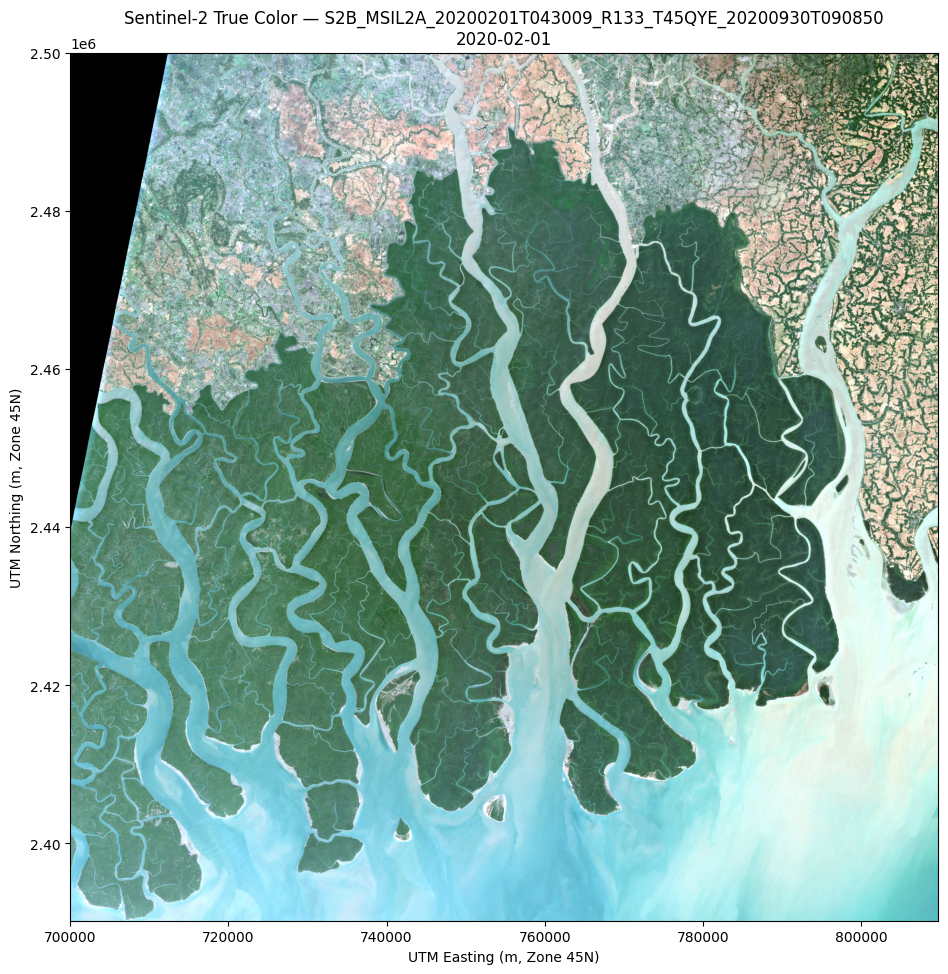

In [16]:
def normalize_pct(band, p_low=2, p_high=98):
    lo, hi = np.percentile(band, [p_low, p_high])
    return np.clip((band - lo) / (hi - lo), 0, 1)

x = data["red"].x.values
y = data["red"].y.values
extent = [x.min(), x.max(), y.min(), y.max()]

rgb = np.stack([
    normalize_pct(data["red"].values),
    normalize_pct(data["green"].values),
    normalize_pct(data["blue"].values),
], axis=-1)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb, extent=extent)
ax.set_title(f"Sentinel-2 True Color — {selected_item_id}\n{selected_item.datetime.date()}")
ax.set_xlabel("UTM Easting (m, Zone 45N)")
ax.set_ylabel("UTM Northing (m, Zone 45N)")
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_true-color_2026-06-13.png", dpi=150)
plt.show()

NaN-Pixel: 3,765,100 (3.12%)
NDVI min: -0.9979296066252588 max: 0.99949609473419 mean: 0.252391152314466


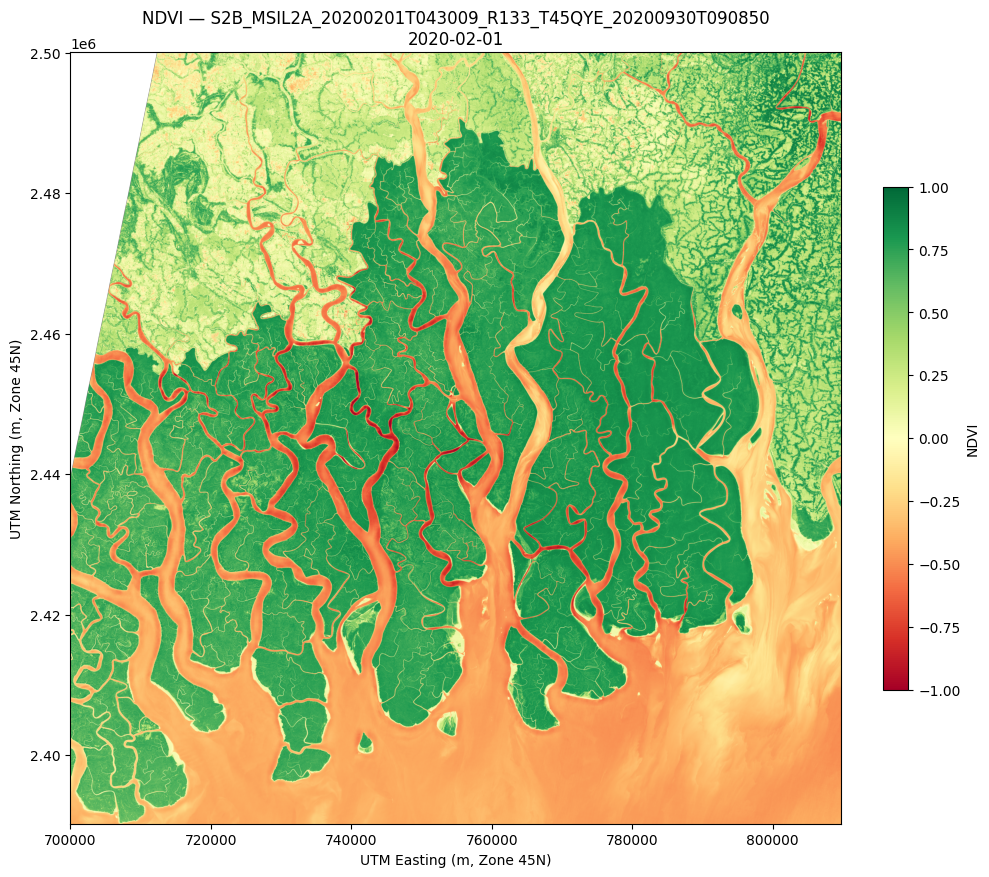

In [17]:
red = data["red"].values.astype(float)
nir = data["nir"].values.astype(float)

with np.errstate(divide="ignore", invalid="ignore"):
    ndvi = (nir - red) / (nir + red)

n_nan = np.isnan(ndvi).sum()
print(f"NaN-Pixel: {n_nan:,} ({100*n_nan/ndvi.size:.2f}%)")
print("NDVI min:", np.nanmin(ndvi), "max:", np.nanmax(ndvi), "mean:", np.nanmean(ndvi))

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1, extent=extent)
ax.set_title(f"NDVI — {selected_item_id}\n{selected_item.datetime.date()}")
ax.set_xlabel("UTM Easting (m, Zone 45N)")
ax.set_ylabel("UTM Northing (m, Zone 45N)")
plt.colorbar(im, ax=ax, label="NDVI", fraction=0.03)
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_ndvi_2026-06-13.png", dpi=150)
plt.show()

# Projection onto new CRS

GMW-Polygone im Ausschnitt: 2073


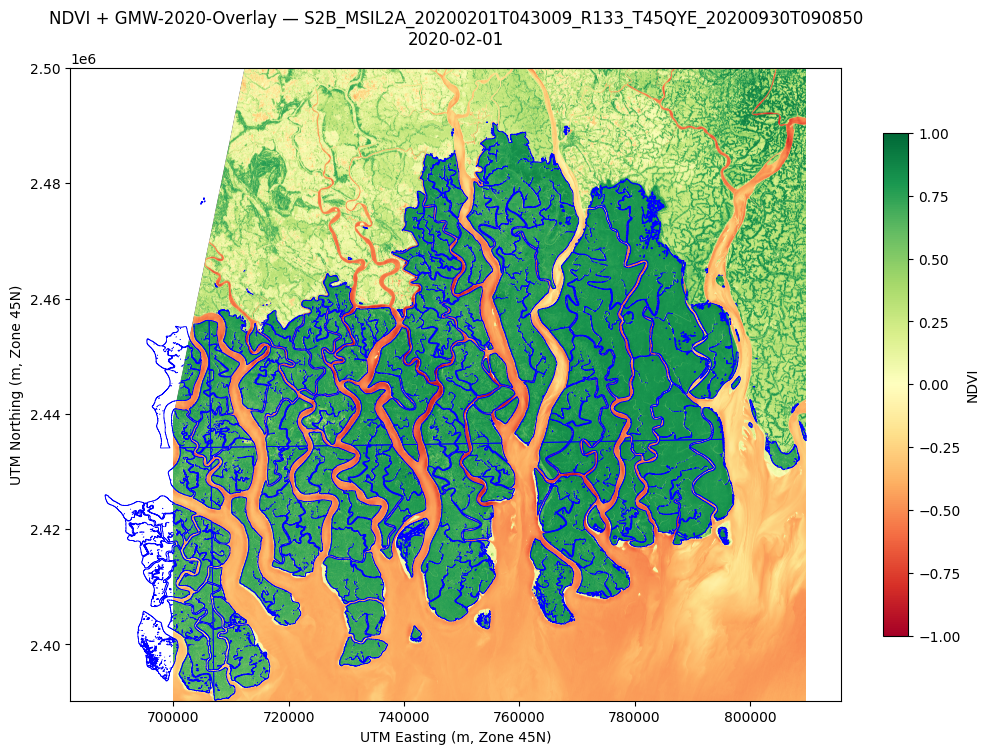

In [18]:
bounds = data["red"].rio.bounds()
gmw_utm = gmw_2020.to_crs(data["red"].rio.crs)
gmw_clip = gmw_utm.cx[bounds[0]:bounds[2], bounds[1]:bounds[3]]

print(f"GMW-Polygone im Ausschnitt: {len(gmw_clip)}")

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1, extent=extent)
gmw_clip.boundary.plot(ax=ax, color="blue", linewidth=0.6)
ax.set_title(f"NDVI + GMW-2020-Overlay — {selected_item_id}\n{selected_item.datetime.date()}")
ax.set_xlabel("UTM Easting (m, Zone 45N)")
ax.set_ylabel("UTM Northing (m, Zone 45N)")
plt.colorbar(im, ax=ax, label="NDVI", fraction=0.03)
plt.tight_layout()
plt.savefig("../assets/screenshots/03-s1_ndvi-gmw-overlay_2026-06-13.png", dpi=150)
plt.show()